In [ ]:
import torch
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# When you execute a code to plot with a simple SHIFT-ENTER, the plot will be shown directly under the code cell
%matplotlib inline

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Load datasets from sci-kit learn
iris = load_iris()
X = iris.data
y = iris.target

# Split training dataset size to be training and validation dataset, set random state for reproducible result
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=0, stratify=y)

# Scale dataset
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Convert to PyTorch Tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)

In [ ]:
class IrisMLP(nn.Module):
    def __init__(self, input_size=4, num_classes=3):
        super(IrisMLP, self).__init__()

        # First hidden layer
        self.fc1 = nn.Linear(input_size, 16)
        self.bn1 = nn.BatchNorm1d(16)

        # Second hidden layer
        self.fc2 = nn.Linear(16, 8)
        self.bn2 = nn.BatchNorm1d(8)

        # Output layer
        self.fc3 = nn.Linear(8, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # First block: FC → BN → ReLU → Dropout
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        # Second block: FC → BN → ReLU → Dropout
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        # Output: FC (no BN, no ReLU, no Dropout)
        x = self.fc3(x)
        return x

# Function to reset model weights for fair comparison
def reset_model(model):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            nn.init.kaiming_normal_(layer.weight, mode='fan_out', nonlinearity='relu')
            if layer.bias is not None:
                nn.init.constant_(layer.bias, 0)
        elif isinstance(layer, nn.BatchNorm1d):
            nn.init.constant_(layer.weight, 1)
            nn.init.constant_(layer.bias, 0)

criterion = nn.CrossEntropyLoss()

In [ ]:
# Extract all model weights into a single 1D vector
def get_weights_as_vector(model):
    params = []
    for param in model.parameters():
        params.append(param.data.view(-1))
    return torch.cat(params)

# Set model weights from a 1D vector
def set_weights_from_vector(model, weight_vector):
    idx = 0
    for param in model.parameters():
        param_size = param.numel()
        param.data.copy_(weight_vector[idx:idx + param_size].view(param.shape))
        idx += param_size

# Evaluate model accuracy as fitness
def evaluate_fitness(model, X_val, y_val):
    model.eval()
    with torch.no_grad():
        outputs = model(X_val)
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == y_val).sum().item() / len(y_val)
    return accuracy

In [ ]:
# Training hyperparameters
num_epochs = 50
learning_rate = 0.01

# Initialize fresh model
model_adam = IrisMLP().to(device)
reset_model(model_adam)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=learning_rate, weight_decay=1e-4)

# Tracking lists for Adam
adam_train_losses = []
adam_train_accs = []
adam_val_losses = []
adam_val_accs = []

for epoch in range(num_epochs):
    # Training
    model_adam.train()
    outputs = model_adam(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer_adam.zero_grad()
    loss.backward()
    optimizer_adam.step()

    # Calculate training accuracy
    _, predicted = torch.max(outputs, 1)
    train_acc = 100 * (predicted == y_train_tensor).sum().item() / len(y_train_tensor)

    # Validation
    model_adam.eval()
    with torch.no_grad():
        val_outputs = model_adam(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        _, val_predicted = torch.max(val_outputs, 1)
        val_acc = 100 * (val_predicted == y_val_tensor).sum().item() / len(y_val_tensor)

    # Store metrics
    adam_train_losses.append(loss.item())
    adam_train_accs.append(train_acc)
    adam_val_losses.append(val_loss.item())
    adam_val_accs.append(val_acc)

    if (epoch + 1) % 5 == 0:
        print(f"Adam - Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {loss.item():.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc:.2f}%")

print(f"Adam Best Val Acc: {max(adam_val_accs):.2f}%")

Adam - Epoch [5/50] Train Loss: 1.2432, Train Acc: 51.67% | Val Loss: 1.0247, Val Acc: 56.67%
Adam - Epoch [10/50] Train Loss: 0.7894, Train Acc: 65.83% | Val Loss: 0.5630, Val Acc: 80.00%
Adam - Epoch [15/50] Train Loss: 0.6312, Train Acc: 72.50% | Val Loss: 0.3743, Val Acc: 86.67%
Adam - Epoch [20/50] Train Loss: 0.4570, Train Acc: 82.50% | Val Loss: 0.2681, Val Acc: 93.33%
Adam - Epoch [25/50] Train Loss: 0.3277, Train Acc: 88.33% | Val Loss: 0.1956, Val Acc: 96.67%
Adam - Epoch [30/50] Train Loss: 0.3314, Train Acc: 82.50% | Val Loss: 0.1507, Val Acc: 100.00%
Adam - Epoch [35/50] Train Loss: 0.2595, Train Acc: 89.17% | Val Loss: 0.1101, Val Acc: 100.00%
Adam - Epoch [40/50] Train Loss: 0.2774, Train Acc: 90.00% | Val Loss: 0.0846, Val Acc: 100.00%
Adam - Epoch [45/50] Train Loss: 0.2306, Train Acc: 89.17% | Val Loss: 0.0714, Val Acc: 100.00%
Adam - Epoch [50/50] Train Loss: 0.2327, Train Acc: 90.00% | Val Loss: 0.0636, Val Acc: 100.00%
Adam Best Val Acc: 100.00%


In [ ]:
# Create fresh model for ES
model_es = IrisMLP().to(device)
reset_model(model_es)

# ES Hyperparameters
population_size = 20
sigma = 0.1
num_generations = 50

# Tracking lists for ES
es_train_losses = []
es_train_accs = []
es_val_losses = []
es_val_accs = []
es_best_fitness = []

# Get initial parent weights
parent_weights = get_weights_as_vector(model_es)
param_count = len(parent_weights)

for generation in range(num_generations):
    # Create population by adding noise to parent weights
    population_weights = []
    population_fitness = []

    for i in range(population_size):
        noise = torch.randn(param_count).to(device) * sigma
        child_weights = parent_weights + noise
        population_weights.append(child_weights)

    # Evaluate population
    for child_weights in population_weights:
        set_weights_from_vector(model_es, child_weights)
        fitness = evaluate_fitness(model_es, X_val_tensor, y_val_tensor)
        population_fitness.append(fitness)

    # Pick best performing models
    # Convert to tensor for easier manipulation
    population_fitness = torch.tensor(population_fitness)

    # Select top performers (top 25% or at least 1)
    top_k = max(1, population_size // 4)
    top_indices = torch.argsort(population_fitness, descending=True)[:top_k]

    # Weighted average based on fitness for new parent
    new_parent = torch.zeros(param_count).to(device)
    total_fitness = 0
    for idx in top_indices:
        fitness = population_fitness[idx]
        new_parent += population_weights[idx] * fitness
        total_fitness += fitness

    new_parent /= total_fitness
    parent_weights = new_parent

    # Evalute parent model
    # Set model to parent weights and evaluate
    set_weights_from_vector(model_es, parent_weights)

    model_es.eval()
    with torch.no_grad():
        # Training metrics
        train_outputs = model_es(X_train_tensor)
        train_loss = criterion(train_outputs, y_train_tensor)
        _, train_predicted = torch.max(train_outputs, 1)
        train_acc = 100 * (train_predicted == y_train_tensor).sum().item() / len(y_train_tensor)

        # Validation metrics
        val_outputs = model_es(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        _, val_predicted = torch.max(val_outputs, 1)
        val_acc = 100 * (val_predicted == y_val_tensor).sum().item() / len(y_val_tensor)

    # Store metrics
    es_train_losses.append(train_loss.item())
    es_train_accs.append(train_acc)
    es_val_losses.append(val_loss.item())
    es_val_accs.append(val_acc)
    es_best_fitness.append(population_fitness.max().item())

    if (generation + 1) % 5 == 0:
        print(f"ES - Generation [{generation+1}/{num_generations}] "
              f"Train Loss: {train_loss.item():.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc:.2f}%, "
              f"Best Fitness: {population_fitness.max().item():.4f}")

print(f"ES Best Val Acc: {max(es_val_accs):.2f}%")

ES - Generation [5/50] Train Loss: 0.8307, Train Acc: 57.50% | Val Loss: 0.8410, Val Acc: 66.67%, Best Fitness: 0.7667
ES - Generation [10/50] Train Loss: 0.7077, Train Acc: 74.17% | Val Loss: 0.7712, Val Acc: 80.00%, Best Fitness: 0.8667
ES - Generation [15/50] Train Loss: 0.6094, Train Acc: 80.00% | Val Loss: 0.6732, Val Acc: 86.67%, Best Fitness: 0.8667
ES - Generation [20/50] Train Loss: 0.5514, Train Acc: 83.33% | Val Loss: 0.5791, Val Acc: 86.67%, Best Fitness: 0.8667
ES - Generation [25/50] Train Loss: 0.5214, Train Acc: 87.50% | Val Loss: 0.5303, Val Acc: 86.67%, Best Fitness: 0.9000
ES - Generation [30/50] Train Loss: 0.4087, Train Acc: 91.67% | Val Loss: 0.3910, Val Acc: 96.67%, Best Fitness: 0.9667
ES - Generation [35/50] Train Loss: 0.4505, Train Acc: 92.50% | Val Loss: 0.4112, Val Acc: 96.67%, Best Fitness: 1.0000
ES - Generation [40/50] Train Loss: 0.3852, Train Acc: 92.50% | Val Loss: 0.3355, Val Acc: 100.00%, Best Fitness: 1.0000
ES - Generation [45/50] Train Loss: 0.37

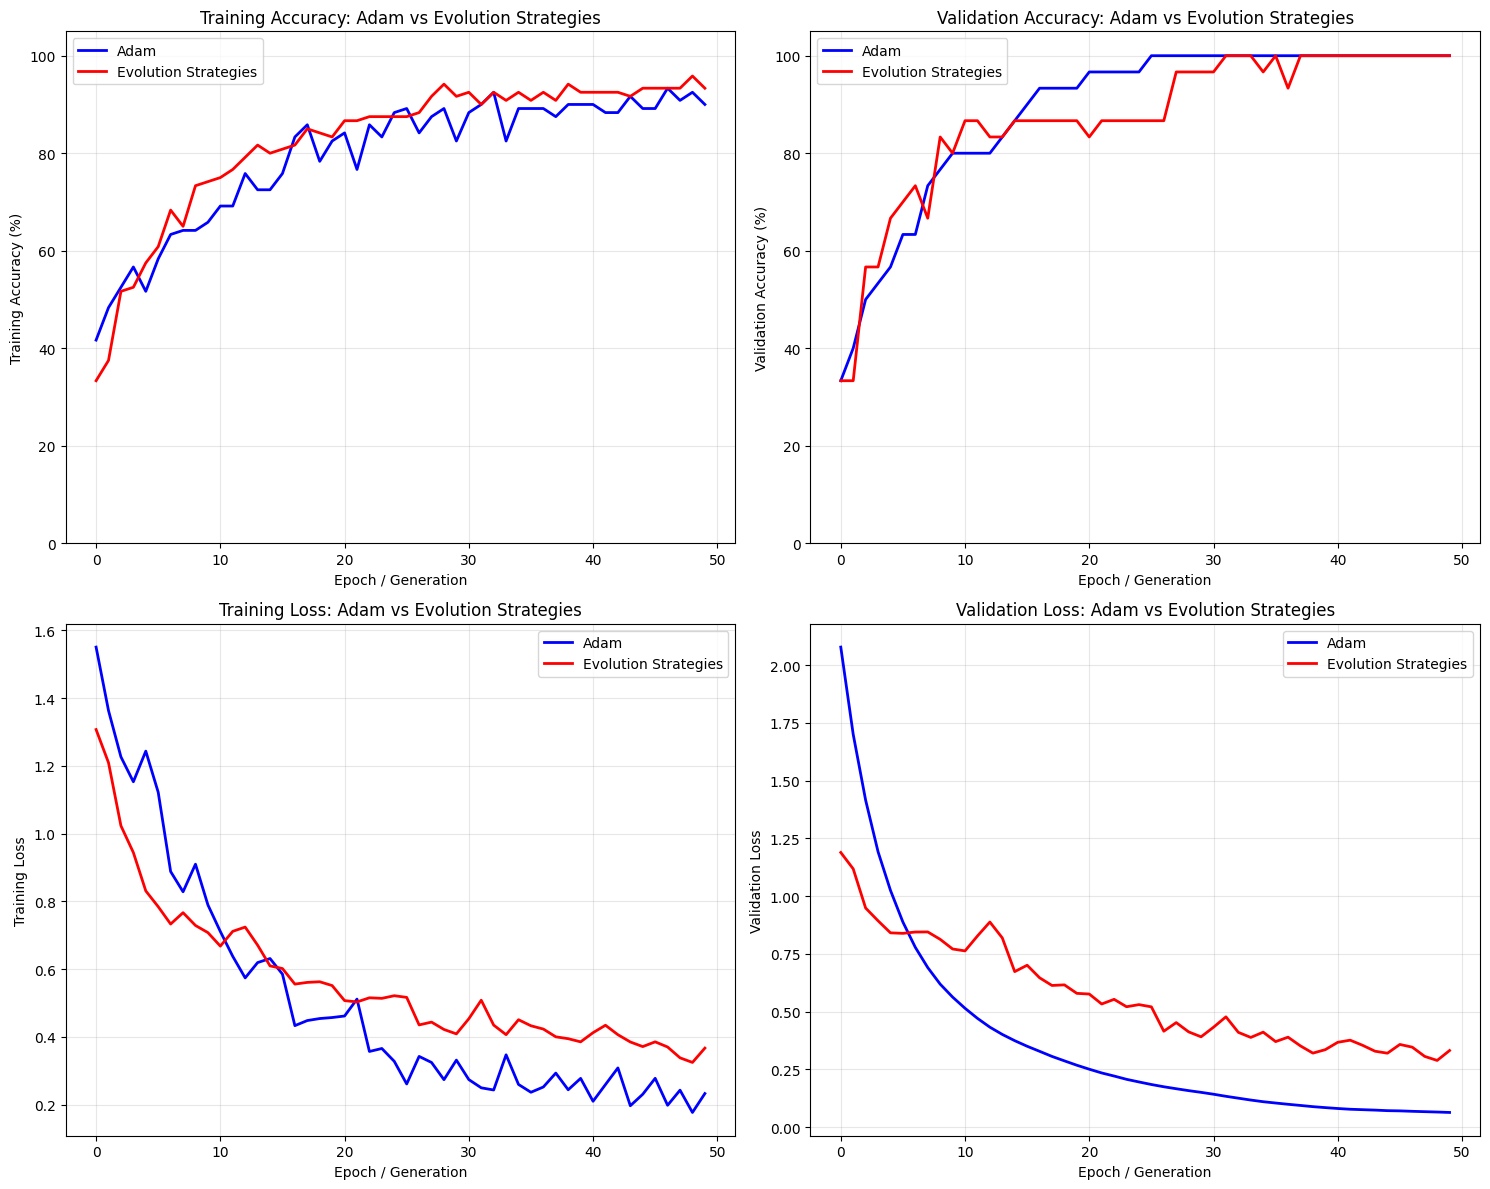

In [ ]:
# Create figure with 2x2 subplots (4 plots total)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Training Accuracy Comparison (Top-Left)
axes[0, 0].plot(adam_train_accs, label='Adam', linewidth=2, color='blue')
axes[0, 0].plot(es_train_accs, label='Evolution Strategies', linewidth=2, color='red')
axes[0, 0].set_xlabel('Epoch / Generation')
axes[0, 0].set_ylabel('Training Accuracy (%)')
axes[0, 0].set_title('Training Accuracy: Adam vs Evolution Strategies')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0, 105])

# Plot 2: Validation Accuracy Comparison (Top-Right)
axes[0, 1].plot(adam_val_accs, label='Adam', linewidth=2, color='blue')
axes[0, 1].plot(es_val_accs, label='Evolution Strategies', linewidth=2, color='red')
axes[0, 1].set_xlabel('Epoch / Generation')
axes[0, 1].set_ylabel('Validation Accuracy (%)')
axes[0, 1].set_title('Validation Accuracy: Adam vs Evolution Strategies')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0, 105])

# Plot 3: Training Loss Comparison (Bottom-Left)
axes[1, 0].plot(adam_train_losses, label='Adam', linewidth=2, color='blue')
axes[1, 0].plot(es_train_losses, label='Evolution Strategies', linewidth=2, color='red')
axes[1, 0].set_xlabel('Epoch / Generation')
axes[1, 0].set_ylabel('Training Loss')
axes[1, 0].set_title('Training Loss: Adam vs Evolution Strategies')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Validation Loss Comparison (Bottom-Right)
axes[1, 1].plot(adam_val_losses, label='Adam', linewidth=2, color='blue')
axes[1, 1].plot(es_val_losses, label='Evolution Strategies', linewidth=2, color='red')
axes[1, 1].set_xlabel('Epoch / Generation')
axes[1, 1].set_ylabel('Validation Loss')
axes[1, 1].set_title('Validation Loss: Adam vs Evolution Strategies')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Adjust layout and save
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150)
plt.show()

In [ ]:
# ==================== SUMMARY TABLE ====================
print("\n" + "=" * 50)
print("SUMMARY RESULTS")
print("=" * 50)
print(f"{'Metric':<35} {'Adam':<15} {'Evolution Strategies':<20}")
print("-" * 70)
print(f"{'Best Validation Accuracy':<35} {max(adam_val_accs):<15.2f} {max(es_val_accs):<20.2f}")
print(f"{'Final Validation Accuracy':<35} {adam_val_accs[-1]:<15.2f} {es_val_accs[-1]:<20.2f}")
print(f"{'Best Training Accuracy':<35} {max(adam_train_accs):<15.2f} {max(es_train_accs):<20.2f}")
print(f"{'Final Training Accuracy':<35} {adam_train_accs[-1]:<15.2f} {es_train_accs[-1]:<20.2f}")

# Calculate convergence speed (epochs to reach 90% validation accuracy)
def epochs_to_reach(accuracies, target=90):
    for i, acc in enumerate(accuracies):
        if acc >= target:
            return i + 1
    return len(accuracies)

adam_convergence = epochs_to_reach(adam_val_accs, 90)
es_convergence = epochs_to_reach(es_val_accs, 90)

print(f"\n{'Convergence Speed (to 90% val acc)':<35} {adam_convergence:<15} {es_convergence:<20}")


SUMMARY RESULTS
Metric                              Adam            Evolution Strategies
----------------------------------------------------------------------
Best Validation Accuracy            100.00          100.00              
Final Validation Accuracy           100.00          100.00              
Best Training Accuracy              93.33           95.83               
Final Training Accuracy             90.00           93.33               

Convergence Speed (to 90% val acc)  16              28                  
